PROBLEM 1


A)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

price_data = {
    "RELIANCE": [2800, 2850, 2830, 2900, 2880, 2950],
    "INFY": [1450, 1470, 1460, 1490, 1510, 1500],
    "HDFCBANK": [1600, 1580, 1610, 1625, 1615, 1640],
    "TATAMOTORS": [520, 535, 528, 540, 555, 548]
}

trading_days = [f"Day {i}" for i in range(1, 7)]

prices_df = pd.DataFrame(price_data, index=trading_days)

daily_returns = prices_df.pct_change().dropna()

print(daily_returns)

       RELIANCE      INFY  HDFCBANK  TATAMOTORS
Day 2  0.017857  0.013793 -0.012500    0.028846
Day 3 -0.007018 -0.006803  0.018987   -0.013084
Day 4  0.024735  0.020548  0.009317    0.022727
Day 5 -0.006897  0.013423 -0.006154    0.027778
Day 6  0.024306 -0.006623  0.015480   -0.012613


B)

RELIANCE       89.285714
INFY          172.413793
HDFCBANK      156.250000
TATAMOTORS    480.769231
Name: Day 1, dtype: float64
Day 1    1.000000e+06
Day 2    1.011999e+06
Day 3    1.009811e+06
Day 4    1.029347e+06
Day 5    1.036658e+06
Day 6    1.041725e+06
dtype: float64


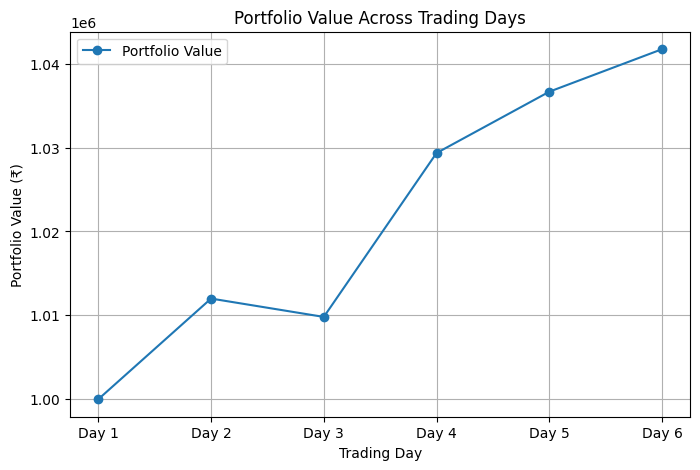

In [2]:
capital = 1000000

allocation = capital * 0.25

units_held = allocation / prices_df.iloc[0]

print(units_held)

portfolio_value = prices_df.mul(units_held, axis=1).sum(axis=1)

print(portfolio_value)

plt.figure(figsize=(8, 5))
plt.plot(portfolio_value.index, portfolio_value.values, marker="o", label="Portfolio Value")
plt.title("Portfolio Value Across Trading Days")
plt.xlabel("Trading Day")
plt.ylabel("Portfolio Value (₹)")
plt.legend()
plt.grid(True)
plt.show()

C)

In [3]:
portfolio_returns = portfolio_value.pct_change().dropna()

daily_volatility = portfolio_returns.std()

annual_volatility = daily_volatility * np.sqrt(252)

print("Annualised Volatility:", annual_volatility)

Annualised Volatility: 0.12753896913611115


PROBLEM 2

A)

In [4]:
np.random.seed(42)

extra_days = 50

simulated_returns = np.random.normal(
    loc=0.001,
    scale=0.015,
    size=extra_days
)

var_95 = -np.percentile(simulated_returns, 5)

var_99 = -np.percentile(simulated_returns, 1)

print("VaR 95%:", var_95)
print("VaR 99%:", var_99)

VaR 95%: 0.025188276651205526
VaR 99%: 0.028054086245915096


B)

In [5]:
tail_95 = simulated_returns[simulated_returns <= -var_95]

tail_99 = simulated_returns[simulated_returns <= -var_99]

cvar_95 = -tail_95.mean()

cvar_99 = -tail_99.mean()

print("CVaR 95%:", cvar_95)
print("CVaR 99%:", cvar_99)

CVaR 95%: 0.027179952619501537
CVaR 99%: 0.028395051858196633


C)

Maximum Drawdown: 0.1816487721165461


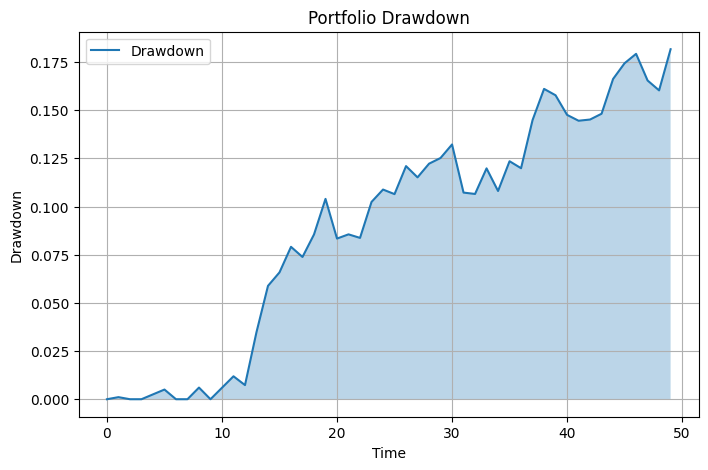

In [6]:
simulated_values = 1000000 * np.cumprod(1 + simulated_returns)

running_peak = np.maximum.accumulate(simulated_values)

drawdown = (running_peak - simulated_values) / running_peak

max_drawdown = drawdown.max()

print("Maximum Drawdown:", max_drawdown)

plt.figure(figsize=(8, 5))

plt.plot(drawdown, label="Drawdown")

plt.fill_between(
    range(len(drawdown)),
    drawdown,
    alpha=0.3
)

plt.title("Portfolio Drawdown")
plt.xlabel("Time")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
PROBLEM 3

A)

In [7]:
np.random.seed(10)

returns_series = np.random.normal(
    loc=0.001,
    scale=0.015,
    size=252
)

risk_free_daily = 0.06 / 252

annual_return = returns_series.mean() * 252

annual_risk = returns_series.std() * np.sqrt(252)

sharpe_ratio = (annual_return - 0.06) / annual_risk

print("Sharpe Ratio:", sharpe_ratio)

Sharpe Ratio: 1.3219288125905744


B)

In [8]:
negative_returns = returns_series[returns_series < 0]

downside_risk = negative_returns.std() * np.sqrt(252)

sortino_ratio = (annual_return - 0.06) / downside_risk

print("Sortino Ratio:", sortino_ratio)

Sortino Ratio: 2.146415861575805


C)

In [9]:
comparison_table = pd.DataFrame({
    "Metric": ["Sharpe Ratio", "Sortino Ratio"],
    "Value": [sharpe_ratio, sortino_ratio]
})

print(comparison_table)

          Metric     Value
0   Sharpe Ratio  1.321929
1  Sortino Ratio  2.146416


PROBLEM 4

A)

In [10]:
np.random.seed(7)

random_returns = np.random.normal(
    loc=0.001,
    scale=0.018,
    size=200
)

price_path = 1000 * np.cumprod(1 + random_returns)

market_df = pd.DataFrame({
    "Price": price_path
})

market_df["SMA_10"] = market_df["Price"].rolling(10).mean()

market_df["SMA_30"] = market_df["Price"].rolling(30).mean()

market_df["Signal"] = 0

market_df.loc[
    market_df["SMA_10"] > market_df["SMA_30"],
    "Signal"
] = 1

market_df.loc[
    market_df["SMA_10"] < market_df["SMA_30"],
    "Signal"
] = -1

print(market_df.head())

         Price  SMA_10  SMA_30  Signal
0  1031.429463     NaN     NaN       0
1  1023.810425     NaN     NaN       0
2  1025.439064     NaN     NaN       0
3  1033.986399     NaN     NaN       0
4  1020.337144     NaN     NaN       0


B)

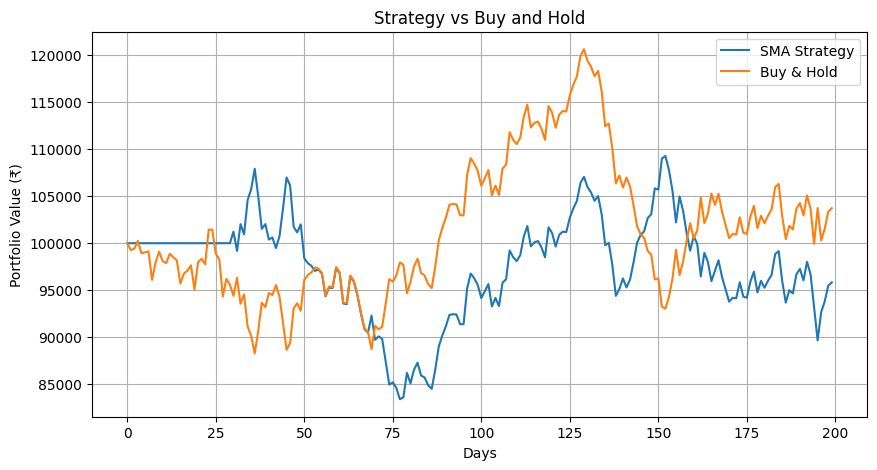

In [11]:
market_df["Asset_Return"] = market_df["Price"].pct_change()

market_df["Strategy_Return"] = (
    market_df["Signal"].shift(1) *
    market_df["Asset_Return"]
)

market_df["Strategy_Return"] = market_df["Strategy_Return"].fillna(0)

initial_money = 100000

strategy_curve = initial_money * (
    1 + market_df["Strategy_Return"]
).cumprod()

buy_hold_curve = initial_money * (
    1 + market_df["Asset_Return"].fillna(0)
).cumprod()

plt.figure(figsize=(10, 5))

plt.plot(strategy_curve, label="SMA Strategy")

plt.plot(buy_hold_curve, label="Buy & Hold")

plt.title("Strategy vs Buy and Hold")

plt.xlabel("Days")

plt.ylabel("Portfolio Value (₹)")

plt.legend()

plt.grid(True)

plt.show()

C)

In [12]:
trade_returns = market_df["Strategy_Return"]

winning_trades = trade_returns[trade_returns > 0]

losing_trades = trade_returns[trade_returns < 0]

win_rate = len(winning_trades) / (
    len(winning_trades) + len(losing_trades)
)

profit_factor = (
    winning_trades.sum() /
    abs(losing_trades.sum())
)

print("Win Rate:", win_rate)

print("Profit Factor:", profit_factor)

Win Rate: 0.5
Profit Factor: 0.9875107127534077


PROBLEM 5

A)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(15)

daily_noise = np.random.normal(
    loc=0.001,
    scale=0.018,
    size=300
)

price_series = 500 * np.cumprod(1 + daily_noise)

asset_df = pd.DataFrame({
    "Price": price_series
})

asset_df["Return_1d"] = asset_df["Price"].pct_change()

asset_df["SMA_5"] = asset_df["Price"].rolling(5).mean()

asset_df["SMA_20"] = asset_df["Price"].rolling(20).mean()

asset_df["Volatility_10"] = (
    asset_df["Return_1d"]
    .rolling(10)
    .std()
)

asset_df["Momentum_5"] = (
    asset_df["Price"]
    - asset_df["Price"].shift(5)
)

asset_df = asset_df.dropna().reset_index(drop=True)

print(asset_df.head())

        Price  Return_1d       SMA_5      SMA_20  Volatility_10  Momentum_5
0  493.877787   0.001268  484.049575  479.620800       0.011013   25.776212
1  493.591322  -0.000580  488.043831  479.415914       0.010830   19.971282
2  485.359146  -0.016678  490.574740  478.622562       0.013232   12.654544
3  486.907650   0.003190  490.597665  477.951905       0.012897    0.114626
4  477.425673  -0.019474  487.432316  477.008084       0.014710  -15.826749


B)

Target
1    141
0    140
Name: count, dtype: int64


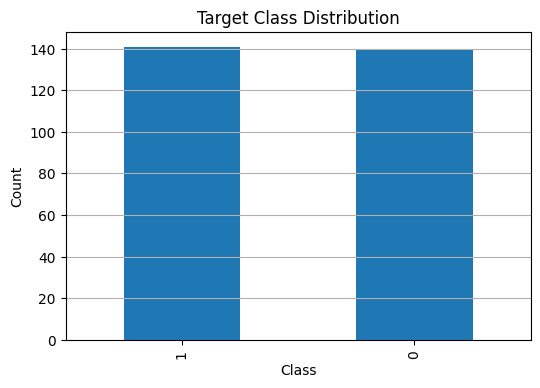

In [14]:
asset_df["Target"] = (
    asset_df["Return_1d"]
    .shift(-1)
    > 0
).astype(int)

asset_df = asset_df.dropna().reset_index(drop=True)

class_counts = asset_df["Target"].value_counts()

print(class_counts)

plt.figure(figsize=(6,4))

class_counts.plot(
    kind="bar"
)

plt.title("Target Class Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.grid(axis="y")

plt.show()

C)

In [15]:
feature_columns = [
    "Return_1d",
    "SMA_5",
    "SMA_20",
    "Volatility_10",
    "Momentum_5"
]

feature_matrix = asset_df[feature_columns]

scaled_features = (
    feature_matrix - feature_matrix.min()
) / (
    feature_matrix.max() - feature_matrix.min()
)

print(scaled_features.head())

   Return_1d     SMA_5    SMA_20  Volatility_10  Momentum_5
0   0.574486  0.289567  0.221144       0.170498    0.724388
1   0.557545  0.314182  0.219643       0.161583    0.679388
2   0.409954  0.329780  0.213833       0.278587    0.622667
3   0.592113  0.329921  0.208920       0.262262    0.525456
4   0.384321  0.310414  0.202008       0.350595    0.401877


PROBLEM 6)

A)

In [16]:
def euclidean_distance(point1, point2):

    distance = np.sqrt(
        np.sum(
            (point1 - point2) ** 2
        )
    )

    return distance

KNN PREDICTION,

In [17]:
def knn_predict(
    train_features,
    train_labels,
    test_features,
    k
):

    predictions = []

    for test_row in test_features:

        distances = np.sqrt(
            np.sum(
                (train_features - test_row) ** 2,
                axis=1
            )
        )

        nearest_indices = np.argsort(distances)[:k]

        nearest_labels = train_labels[nearest_indices]

        predicted_class = np.bincount(
            nearest_labels
        ).argmax()

        predictions.append(predicted_class)

    return np.array(predictions)

B)

In [18]:
X = scaled_features.values

y = asset_df["Target"].values

split_point = int(len(X) * 0.8)

X_train = X[:split_point]

X_test = X[split_point:]

y_train = y[:split_point]

y_test = y[split_point:]

TESTING DIFFERENT K VALUE

In [19]:
k_values = [3, 5, 7, 11, 15]

accuracy_scores = []

for current_k in k_values:

    predicted = knn_predict(
        X_train,
        y_train,
        X_test,
        current_k
    )

    accuracy = np.mean(
        predicted == y_test
    )

    accuracy_scores.append(
        accuracy
    )

    print(
        f"k = {current_k} : {accuracy:.4f}"
    )

k = 3 : 0.5088
k = 5 : 0.5263
k = 7 : 0.4211
k = 11 : 0.4211
k = 15 : 0.3509


PLOTS

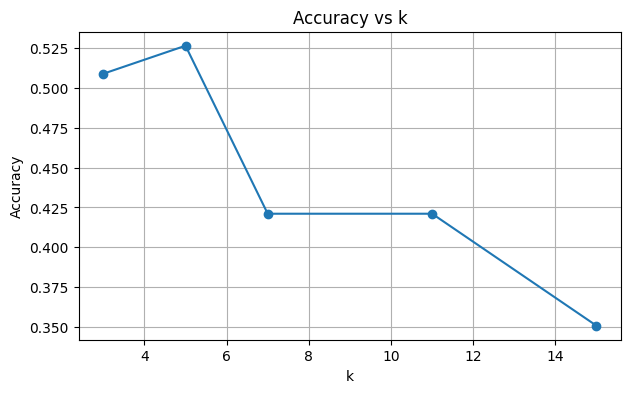

In [20]:
plt.figure(figsize=(7,4))

plt.plot(
    k_values,
    accuracy_scores,
    marker="o"
)

plt.title("Accuracy vs k")

plt.xlabel("k")

plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

BEST K = 5

In [23]:


best_position = np.argmax(
    accuracy_scores
)

best_k = k_values[
    best_position
]

print(best_k)

5


C)

In [24]:
best_predictions = knn_predict(
    X_train,
    y_train,
    X_test,
    best_k
)

components (confusion matrix)

In [25]:
tp = np.sum(
    (y_test == 1) &
    (best_predictions == 1)
)

tn = np.sum(
    (y_test == 0) &
    (best_predictions == 0)
)

fp = np.sum(
    (y_test == 0) &
    (best_predictions == 1)
)

fn = np.sum(
    (y_test == 1) &
    (best_predictions == 0)
)

confusion_matrix = pd.DataFrame(
    [
        [tn, fp],
        [fn, tp]
    ],
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print(confusion_matrix)

          Predicted 0  Predicted 1
Actual 0           13           14
Actual 1           13           17


precision and recall

In [26]:
precision = tp / (tp + fp)

recall = tp / (tp + fn)

print("Precision =", precision)

print("Recall =", recall)

Precision = 0.5483870967741935
Recall = 0.5666666666666667


precision is more imp when the false negetives are expensive trades. More preferale to have a reliable buy signal rather than predicting every upward movement.with high presicion, its more likely to be correct when buying.

PROBLEM 7

A)

In [30]:
asset_df["Next_Return"] = asset_df["Return_1d"].shift(-1)

regression_df = asset_df.dropna().reset_index(drop=True)

X_reg = scaled_features.iloc[:len(regression_df)].values

y_reg = regression_df["Next_Return"].values

split_point_reg = int(len(X_reg) * 0.8)

X_train_reg = X_reg[:split_point_reg]
X_test_reg = X_reg[split_point_reg:]

y_train_reg = y_reg[:split_point_reg]
y_test_reg = y_reg[split_point_reg:]

X_train_bias = np.c_[np.ones(len(X_train_reg)), X_train_reg]
X_test_bias = np.c_[np.ones(len(X_test_reg)), X_test_reg]

beta_normal = np.linalg.inv(
    X_train_bias.T @ X_train_bias
) @ X_train_bias.T @ y_train_reg

print("Normal Equation Coefficients")
print(beta_normal)

coefficient_table = pd.DataFrame({
    "Feature": ["Bias"] + feature_columns,
    "Coefficient": beta_normal
})

print(coefficient_table)


Normal Equation Coefficients
[ 0.00711947  0.00374356 -0.00530201 -0.00552117 -0.00420923 -0.00396777]
         Feature  Coefficient
0           Bias     0.007119
1      Return_1d     0.003744
2          SMA_5    -0.005302
3         SMA_20    -0.005521
4  Volatility_10    -0.004209
5     Momentum_5    -0.003968


B)

MSE = 0.0003483259806449943
R2 = -0.014199664553041558


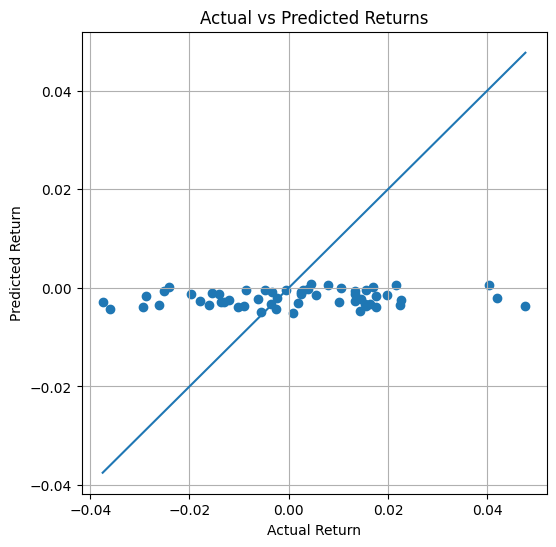

In [31]:

predicted_returns = X_test_bias @ beta_normal

mse_lr = np.mean(
    (y_test_reg - predicted_returns) ** 2
)

r2_lr = 1 - (
    np.sum((y_test_reg - predicted_returns) ** 2)
    /
    np.sum((y_test_reg - np.mean(y_test_reg)) ** 2)
)

print("MSE =", mse_lr)
print("R2 =", r2_lr)

plt.figure(figsize=(6,6))

plt.scatter(
    y_test_reg,
    predicted_returns
)

min_value = min(y_test_reg.min(), predicted_returns.min())
max_value = max(y_test_reg.max(), predicted_returns.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value]
)

plt.xlabel("Actual Return")
plt.ylabel("Predicted Return")
plt.title("Actual vs Predicted Returns")
plt.grid(True)
plt.show()


C)

Gradient Descent Coefficients
[ 0.00167344  0.00158375 -0.00266434 -0.00287901 -0.00024612  0.00049436]


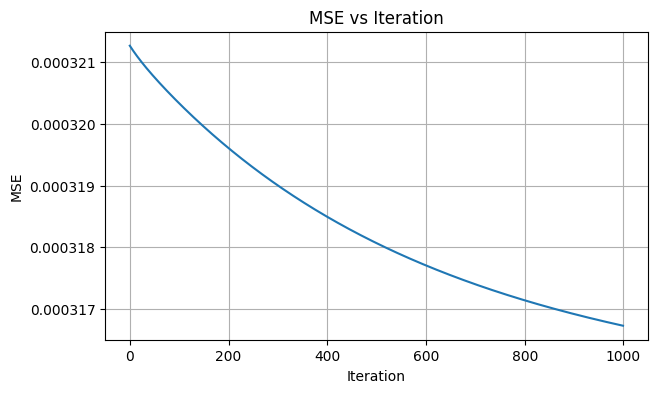

Normal Equation: [ 0.00711947  0.00374356 -0.00530201 -0.00552117 -0.00420923 -0.00396777]
Gradient Descent: [ 0.00167344  0.00158375 -0.00266434 -0.00287901 -0.00024612  0.00049436]


In [32]:

learning_rate = 0.01
iterations = 1000

beta_gd = np.zeros(
    X_train_bias.shape[1]
)

loss_history = []

for iteration in range(iterations):

    predictions_gd = X_train_bias @ beta_gd

    errors = predictions_gd - y_train_reg

    gradient = (
        X_train_bias.T @ errors
    ) / len(X_train_bias)

    beta_gd = beta_gd - learning_rate * gradient

    loss = np.mean(errors ** 2)

    loss_history.append(loss)

print("Gradient Descent Coefficients")
print(beta_gd)

plt.figure(figsize=(7,4))
plt.plot(loss_history)
plt.title("MSE vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

print("Normal Equation:", beta_normal)
print("Gradient Descent:", beta_gd)


PROBLEM 8

A & B

In [33]:
asset_names = [
    "RELIANCE",
    "INFY",
    "HDFCBANK",
    "TATAMOTORS"
]

predicted_mu = []

for asset_name in asset_names:

    asset_prediction = predicted_returns.mean()

    predicted_mu.append(asset_prediction)

predicted_mu = np.array(predicted_mu)

positive_returns = np.maximum(
    predicted_mu,
    0
)

if positive_returns.sum() == 0:
    ml_weights = np.ones(len(asset_names)) / len(asset_names)
else:
    ml_weights = positive_returns / positive_returns.sum()

print("Predicted Returns")
print(predicted_mu)

print("ML Weights")
print(ml_weights)

print("Weight Sum =", ml_weights.sum())


Predicted Returns
[-0.00203734 -0.00203734 -0.00203734 -0.00203734]
ML Weights
[0.25 0.25 0.25 0.25]
Weight Sum = 1.0


C)

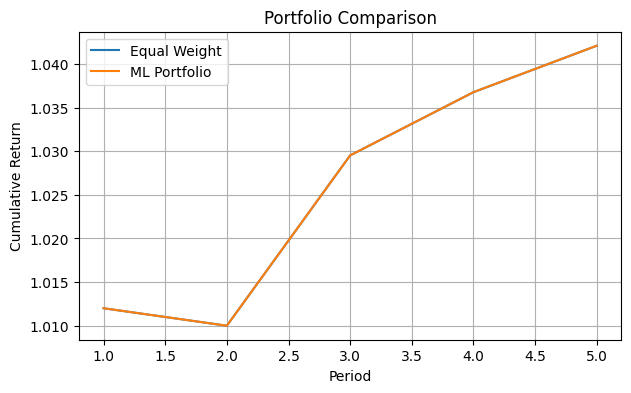

In [35]:
equal_weights = np.ones(4) / 4

price_data = pd.DataFrame({
    "RELIANCE":[2800,2850,2830,2900,2880,2950],
    "INFY":[1450,1470,1460,1490,1510,1500],
    "HDFCBANK":[1600,1580,1610,1625,1615,1640],
    "TATAMOTORS":[520,535,528,540,555,548]
})

asset_returns = price_data.pct_change().dropna()

equal_portfolio_returns = asset_returns.dot(equal_weights)

ml_portfolio_returns = asset_returns.dot(ml_weights)

equal_cumulative = (1 + equal_portfolio_returns).cumprod()

ml_cumulative = (1 + ml_portfolio_returns).cumprod()

plt.figure(figsize=(7,4))

plt.plot(equal_cumulative, label="Equal Weight")
plt.plot(ml_cumulative, label="ML Portfolio")

plt.title("Portfolio Comparison")
plt.xlabel("Period")
plt.ylabel("Cumulative Return")
plt.legend()
plt.grid(True)
plt.show()


PROBLEM 9

A)

In [36]:

folds = np.array_split(
    np.arange(len(X)),
    5
)

knn_cv_results = []

for current_k in [3, 7, 11]:

    fold_accuracies = []

    for fold_index in range(5):

        validation_indices = folds[fold_index]

        training_indices = np.concatenate(
            [folds[i] for i in range(5) if i != fold_index]
        )

        X_train_fold = X[training_indices]
        y_train_fold = y[training_indices]

        X_validation = X[validation_indices]
        y_validation = y[validation_indices]

        fold_predictions = knn_predict(
            X_train_fold,
            y_train_fold,
            X_validation,
            current_k
        )

        fold_accuracy = np.mean(
            fold_predictions == y_validation
        )

        fold_accuracies.append(fold_accuracy)

    knn_cv_results.append([
        current_k,
        np.mean(fold_accuracies),
        np.std(fold_accuracies)
    ])

cv_results_df = pd.DataFrame(
    knn_cv_results,
    columns=["k", "Mean Accuracy", "Std Accuracy"]
)

print(cv_results_df)


    k  Mean Accuracy  Std Accuracy
0   3       0.533772      0.028958
1   7       0.522995      0.087676
2  11       0.555201      0.087209


B)

In [37]:

best_knn_accuracy = max(accuracy_scores)

model_comparison = pd.DataFrame({
    "Model": ["KNN", "Linear Regression"],
    "Accuracy/R2": [best_knn_accuracy, r2_lr],
    "MSE/N.A.": ["N.A.", mse_lr],
    "Best Param": [best_k, "Normal Equation"]
})

print(model_comparison)


               Model  Accuracy/R2  MSE/N.A.       Best Param
0                KNN     0.526316      N.A.                5
1  Linear Regression    -0.014200  0.000348  Normal Equation


C)
depending of the nature of implementation, KNN is for clasifying data while linear regression is to predict when there is continous data. I will use KNN for calsifying the directiopn of price while using regression to predict continous returns.

PROBLEM 10

a)
covariance terms depend on correlation. When correlations are low or negative, the covariance contribution decreases, reducing overall portfolio variance. Assets do not move together, so losses in one asset can be countered by gains in another. This lowers total portfolio volatility without reducing expected return.(already shown the maths of this and equations in assignment 1)

b)
Price-to-Earnings (P/E) ratio. It can be collected from company financial statements or market data providers. The ratio can be merged with technical features by date and stock symbol. KNN can use both valuation and price-action information during prediction.

c)
distances between observations become increasingly similar. The concept of a nearest neighbour becomes less meaningful,making predictions and clasifications inaccurate.increases noise and computational cost due to working in higher dimensions. Principal Component Analysis (PCA) can be used to reduce dimensionality.

d)
Look-ahead bias, survivorship bias, and data snooping can all inflate backtest performance. Walk-forward testing helps detect look-ahead bias. Using historical constituent lists helps detect survivorship bias. Out-of-sample validation helps detect data snooping and excessive parameter tuning.

e)
Financial returns show autocorrelation and heteroscedasticity. current returns may depend on previous returns thats voilated Independence.  volatility changes over time that voilates constant variance(iid). Both issues can make coefficient estimates less accurate(reduse accuracy of model).
